### Example 1

$$
\frac{dx}{dt} = -ax - b \left( \frac{x}{x + y} \right) + I(t)
$$

$$
\frac{dy}{dt} = -cy + b \left( \frac{x}{x + y} \right) + J(t)
$$

The initial conditions are:

$$
x(0) = x_0, \quad y(0) = y_0
$$

Here take the parameter values:

$$
a = 4, \quad b = 2, \quad c = 3
$$

$$
I(t) = 3, \quad J(t) = 2
$$

$$
x_0 = 0.5, \quad y_0 = 0.3
$$

Take:

$$
t \in [0, 5]
$$

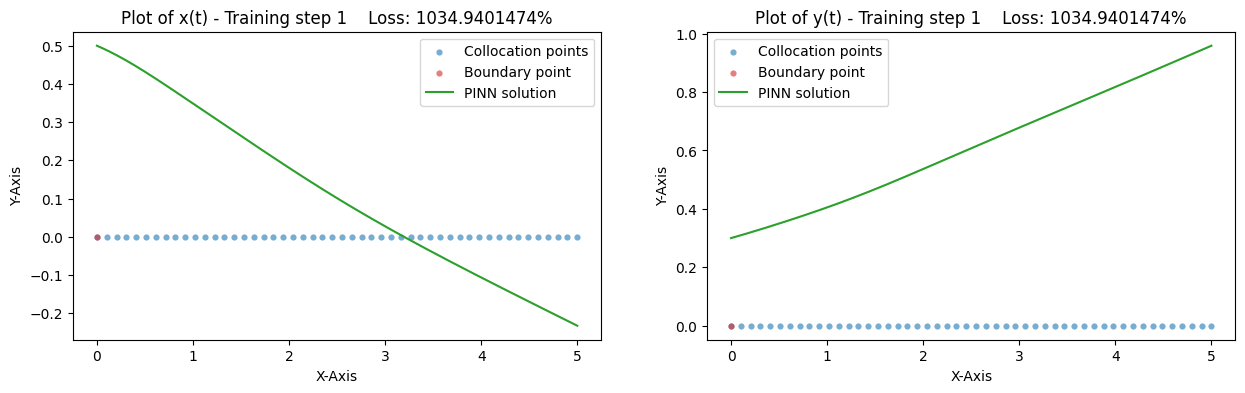

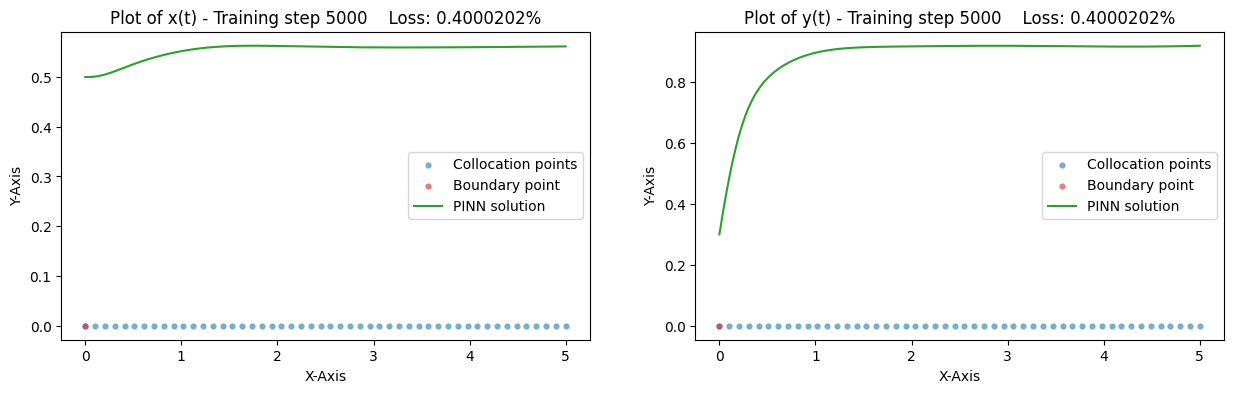

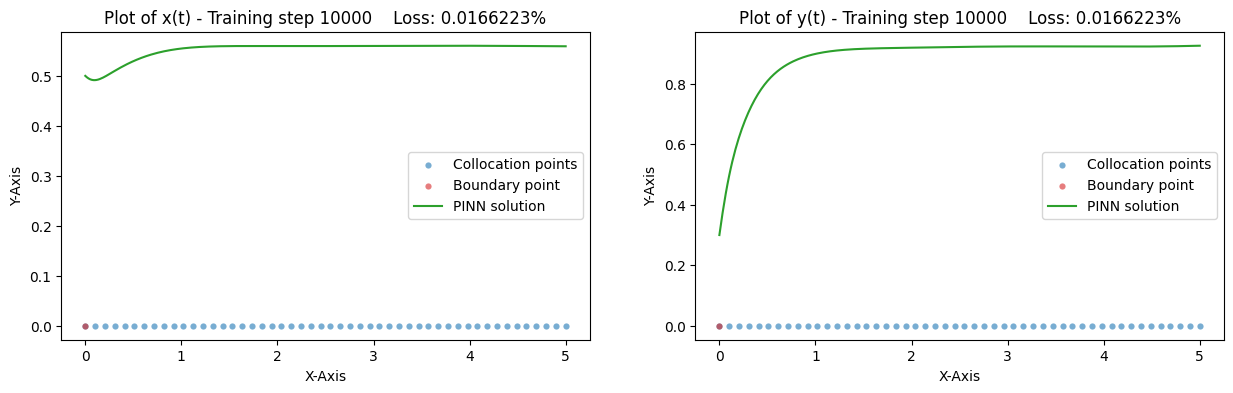

Total training time: 42.934011697769165 seconds


In [ ]:
import time

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


class FCN(nn.Module):
    "Defines a fully-connected network in PyTorch"
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

def get_x(network,t):
  return 0.5 + (t)*network

def get_y(network,t):
  return 0.3 + (t)*network
torch.manual_seed(123)

# define a neural network to train
pinn = FCN(1,2,32,4)

# define boundary points, for the boundary loss
# TODO # (1, 1)
t_boundary = torch.tensor(0.,requires_grad=True).reshape(-1,1)

# define training points over the entire domain, for the physics loss
# TODO # (30, 1)
t_physics = torch.linspace(0,5,50, requires_grad=True).reshape(-1,1)

# train the PINN
t_test = torch.linspace(0,5,300).view(-1,1)
optimiser = torch.optim.Adam(pinn.parameters(),lr=1e-4)
start = time.time()
for j in range(10000):
    optimiser.zero_grad()

    # compute each term of the PINN loss function above
    # using the following hyperparameters


    # compute physics loss
    # TODO
    x = pinn(t_physics)[:,0:1]
    x = get_x(x,t_physics)
    y = pinn(t_physics)[:,1:2]
    y = get_y(y,t_physics)
    dxdt = torch.autograd.grad(x, t_physics, torch.ones_like(x), create_graph=True)[0]
    dydt = torch.autograd.grad(y, t_physics, torch.ones_like(y), create_graph=True)[0]
    loss1 = torch.mean((dxdt+(4*x)+2*(x/(x+y)) - 3)**2)
    loss2 = torch.mean((dydt+(3*y)-2*(x/(x+y)) - 2)**2)


    # backpropagate joint loss, take optimiser step
    loss = loss1+loss2
    loss.backward()
    optimiser.step()

    # plot the result as training progresses
    if (j+1)%5000 == 0 or j==0:
        x = pinn(t_test)[:,0:1].detach()
        x = get_x(x,t_test)
        y = pinn(t_test)[:,1:2].detach()
        y = get_y(y,t_test)

        #Plotting x
        plt.figure(figsize=(15,4))
        plt.subplot(1,2,1)
        plt.scatter(t_physics.detach()[:,0], torch.zeros_like(t_physics)[:,0], s=20, lw=0, color="tab:blue", alpha=0.6, label="Collocation points")
        plt.scatter(t_boundary.detach()[:,0], 0, s=20, lw=0, color="tab:red", alpha=0.6, label="Boundary point")
        plt.plot(t_test[:,0], x, label="PINN solution", color="tab:green")
        plt.xlabel("X-Axis")
        plt.ylabel("Y-Axis")
        plt.title(f"Plot of x(t) - Training step {j+1}    Loss: {loss:.7%}")
        plt.legend()

        #Plotting y
        plt.subplot(1,2,2)
        plt.scatter(t_physics.detach()[:,0], torch.zeros_like(t_physics)[:,0], s=20, lw=0, color="tab:blue", alpha=0.6, label="Collocation points")
        plt.scatter(t_boundary.detach()[:,0], 0, s=20, lw=0, color="tab:red", alpha=0.6, label="Boundary point")
        plt.plot(t_test[:,0], y, label="PINN solution", color="tab:green")
        plt.xlabel("X-Axis")
        plt.ylabel("Y-Axis")
        plt.title(f"Plot of y(t) - Training step {j+1}    Loss: {loss:.7%}")
        plt.legend()

        plt.show()

print(f"Total training time: {time.time()-start} seconds")

# **Inverse Problem -**

$$
\frac {dx}{dt} = -ax -b(\frac {x}{x+y}) + 3
$$
$$
\frac {dy}{dt} = -cy +b(\frac {x}{x+y}) + 2
$$
$$
$$
$$
x(0) = 0.5,y(0) = 0.3
$$
$$
tϵ[0,5]
$$
$$
a = 4,b=2,c=3
$$

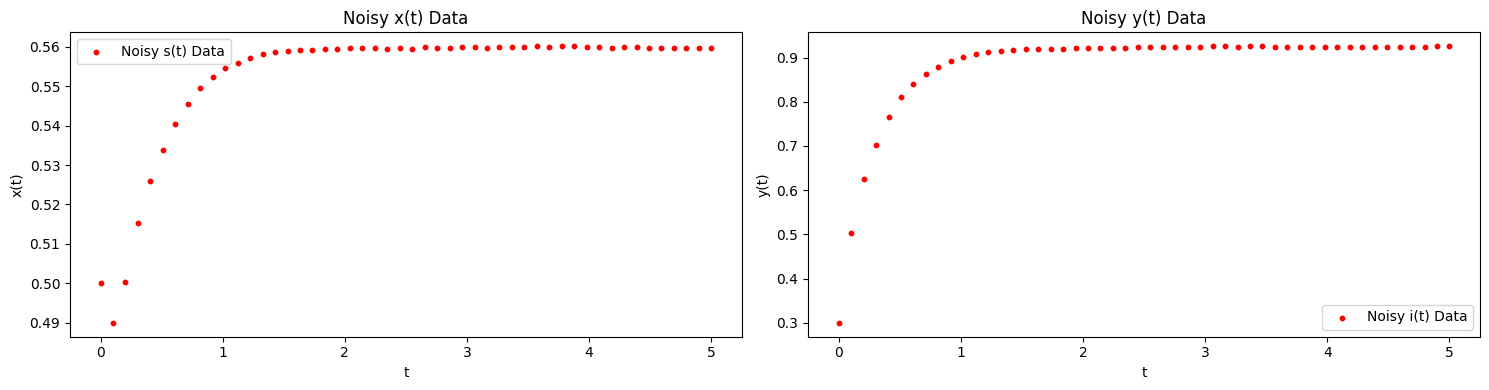

In [ ]:
# Generate Noisy Data

t_data = torch.linspace(0, 5, 50).view(-1, 1)
torch.manual_seed(123)

# Use the trained PINN to generate 'true' u and v values
with torch.no_grad():
    pinn_output_data = pinn(t_data)
    x_true = pinn_output_data[:, 0:1]
    x_true = get_x(x_true,t_data)
    y_true = pinn_output_data[:, 1:2]
    y_true = get_y(y_true,t_data)



# Add Gaussian noise to the 'true' data
x_noisy = x_true + 1e-4 * torch.randn_like(x_true)
y_noisy = y_true + 1e-4 * torch.randn_like(y_true)

# Plot the true vs. noisy data to visualize
plt.figure(figsize=(15, 4))

plt.subplot(1, 2, 1)
plt.scatter(t_data, x_noisy, label='Noisy s(t) Data', color='red', s=10)
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('Noisy x(t) Data')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(t_data, y_noisy, label='Noisy i(t) Data', color='red', s=10)
plt.xlabel('t')
plt.ylabel('y(t)')
plt.title('Noisy y(t) Data')
plt.legend()

plt.tight_layout()
plt.show()

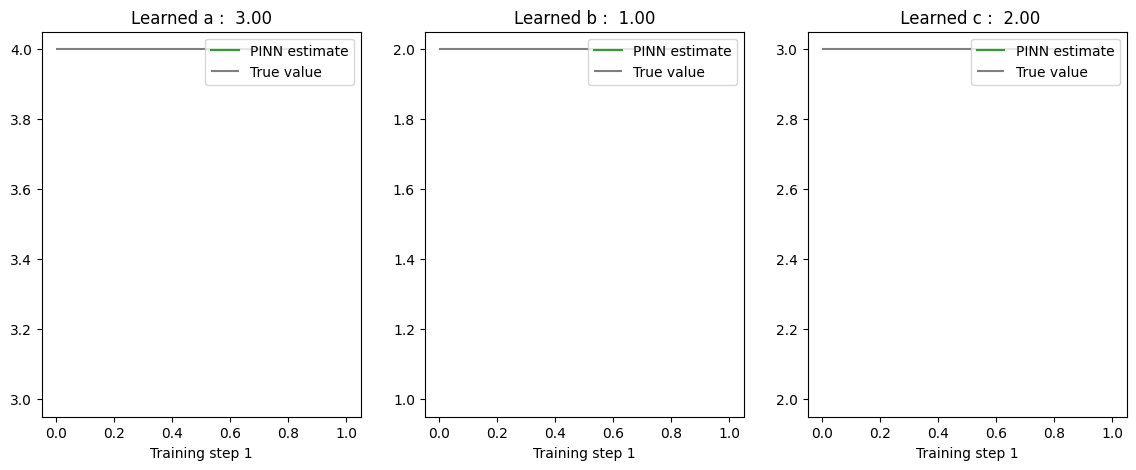

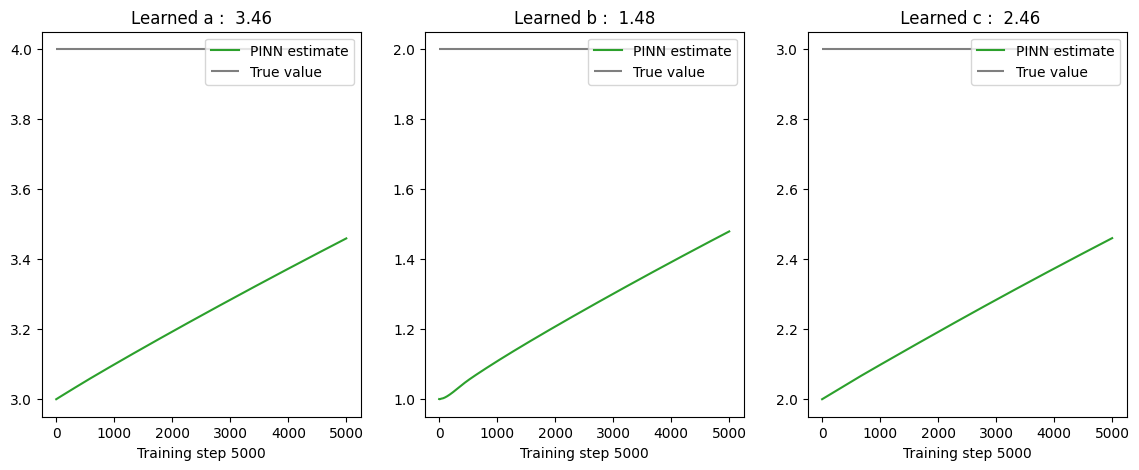

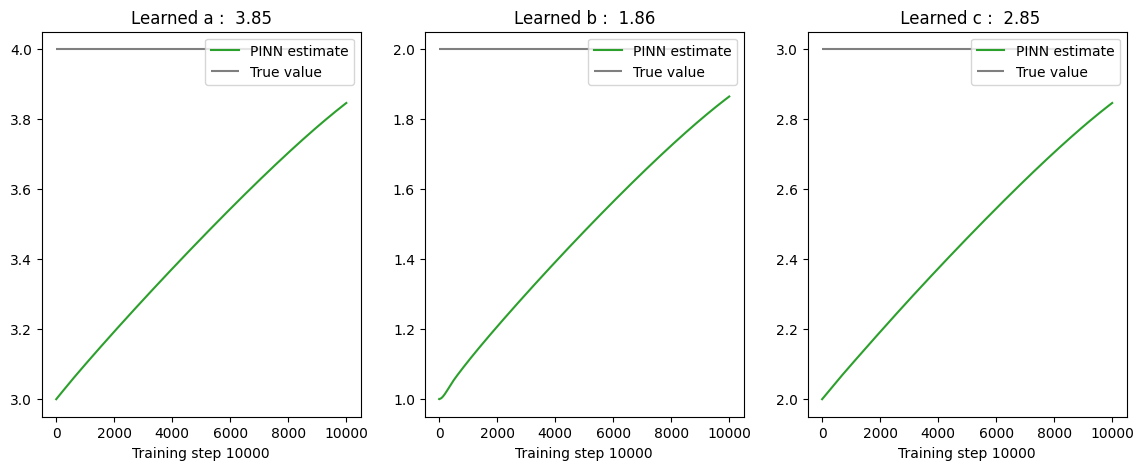

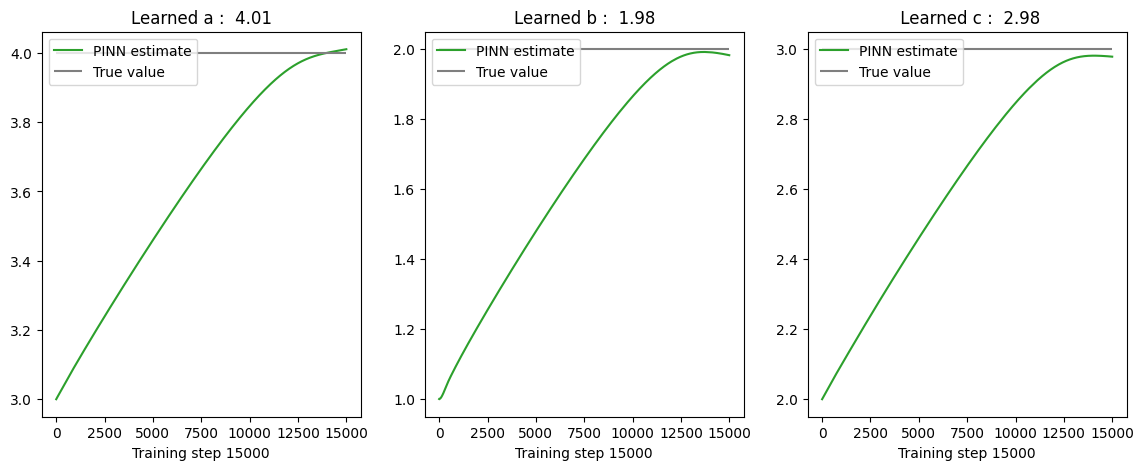

Total training time: 73.5326476097107 seconds
Learned a : 4.0106730461120605
Learned b : 1.9829189777374268
Learned c : 2.978745222091675


In [ ]:
torch.manual_seed(123)

# define a neural network to train
pinn = FCN(1,2,32,4)


# define training points over the entire domain, for the physics loss
t_physics = torch.linspace(0,5,64).view(-1,1).requires_grad_(True)

# train the PINN
t_test = torch.linspace(0,5,300).view(-1,1)

# treat alpha,beta,gamma and delta as a learnable parameter, add it to optimiser
# TODO

alpha = torch.nn.Parameter(torch.tensor(3.))
beta= torch.nn.Parameter(torch.tensor(1.))
gamma = torch.nn.Parameter(torch.tensor(2.))

optimiser = torch.optim.Adam(list(pinn.parameters()) + [alpha,beta,gamma],lr=1e-4)
alphas = []
betas = []
gammas = []
start = time.time()
for j in range(15000):
    optimiser.zero_grad()

    # compute each term of the PINN loss function above
    # using the following hyperparameters
    lambda1,lambda2,lambda3 = 1,1,1e3

    # compute physics loss
    pred = pinn(t_physics)
    x = pred[:,0:1]
    x = get_x(x,t_physics)
    y = pred[:,1:2]
    y = get_y(y,t_physics)
    dxdt = torch.autograd.grad(x, t_physics, torch.ones_like(x), create_graph=True)[0]
    dydt = torch.autograd.grad(y, t_physics, torch.ones_like(y), create_graph=True)[0]
    loss1 = torch.mean((dxdt + alpha*x + beta*(x/(x+y)) - 3)**2)
    loss2 = torch.mean((dydt + gamma*y - beta*(x/(x+y)) - 2)**2)

    # compute data loss
    # TODO
    prediction = pinn(t_data)
    x_obs = prediction[:,0:1]
    x_obs = get_x(x_obs,t_data)
    y_obs = prediction[:,1:2]
    y_obs = get_y(y_obs,t_data)
    loss3 = torch.mean((x_noisy-x_obs)**2) + torch.mean((y_noisy-y_obs)**2)

    loss = lambda1*loss1 + lambda2*loss2 + lambda3*loss3
    loss.backward()
    optimiser.step()

    # record mu value
    alphas.append(alpha.item())
    betas.append(beta.item())
    gammas.append(gamma.item())

    # plot the result as training progresses
    if (j+1)%5000 == 0 or j==0:

        plt.figure(figsize=(14,5))

        plt.subplot(1,3,1)
        plt.title(f"Learned a : {alpha.item(): .2f}")
        plt.plot(alphas, label="PINN estimate", color="tab:green")
        plt.hlines(4, 0, len(alphas), label="True value", color="tab:grey")
        plt.xlabel(f"Training step {j+1}")
        plt.legend()

        plt.subplot(1,3,2)
        plt.title(f"Learned b : {beta.item(): .2f}")
        plt.plot(betas, label="PINN estimate", color="tab:green")
        plt.hlines(2, 0, len(betas), label="True value", color="tab:grey")
        plt.xlabel(f"Training step {j+1}")
        plt.legend()

        plt.subplot(1,3,3)
        plt.title(f" Learned c : {gamma.item(): .2f}")
        plt.plot(gammas, label="PINN estimate", color="tab:green")
        plt.hlines(3, 0, len(gammas), label="True value", color="tab:grey")
        plt.xlabel(f"Training step {j+1}")
        plt.legend()

        plt.show()

print(f"Total training time: {time.time()-start} seconds")
print(f"Learned a : {alpha.item()}")
print(f"Learned b : {beta.item()}")
print(f"Learned c : {gamma.item()}")